# 17. Truncating the Tidal Expansion

TidalPy writes the tidal potential as a sum of Kaula (1964) modes. Each mode carries an eccentricity function $G_{lpq}(e)$ and an obliquity function $F_{lmp}(I)$ and forces the body at one frequency. The eccentricity functions are infinite series in $e$, so a calculation has to decide where to stop. That choice is the eccentricity truncation level, and it sets both the accuracy and the cost of every tidal calculation.

Level $N$ keeps every product of two eccentricity functions through $e^N$. The heating, the torques, and the orbital rates are all quadratic in the potential, so their Taylor series in $e$ are then complete through $e^N$: level 2 is the classic $e^2$ theory. The tabulated levels are 2, 4, 6, 8, 10 (the default), 20, and 50. Past about $e = 0.75$ no tabulated level is reliable, and the `"exact"` option computes the eccentricity functions from the exact Kepler orbit instead, keeping as many modes as a tolerance asks for. The obliquity functions use the same language, with levels `"off"`, 2, 4, and `"gen"`. The [eccentricity](../../Documentation/Tides_x/eccentricity.md) and [obliquity](../../Documentation/Tides_x/obliquity.md) pages of the documentation explain how the levels are built.

This notebook shows when the choice matters: the heating and the eccentricity damping rate against eccentricity at each level, how many modes the exact functions need, what each level costs, and the helpers that pick a level for you.

In [1]:
%matplotlib inline
import timeit

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.structures_x.configs import build_world
from TidalPy.structures_x.system import System
from TidalPy.Tides_x.potential import global_potential
from TidalPy.Tides_x.eccentricity import (ECCENTRICITY_TRUNCATIONS, eccentricity_accuracy_limit,
                                          recommend_eccentricity_truncation)
from TidalPy.Tides_x.obliquity import recommend_obliquity_truncation

# A homogeneous Maxwell Io. Its Maxwell time (about 2 days) sits near the forcing periods, so the Love number,
# and with it each mode's share of the heating, depends strongly on frequency.
RADIUS, MASS = 1.8216e6, 8.9319e22
SHEAR, VISCOSITY = 6.0e10, 1.0e16


def maxwell_io(love_method="homogeneous"):
    world = build_world({
        "schema_version": "0.2.0", "name": "Io", "type": "terrestrial", "radius_m": RADIUS, "mass_kg": MASS,
        "tides": {"global_tidal_model": "rheology", "love_method": love_method},
        "layers": {"body": {
            "class": "solidliquid", "layer_index": 0, "radius_fraction": 1.0, "is_tidal": True,
            "is_static": False,
            "material": {"model": "constant", "reference_density_kg_m3": MASS / (4.0 / 3.0 * np.pi * RADIUS**3),
                         "shear_modulus_static_pa": SHEAR, "bulk_modulus_static_pa": 2.0 * SHEAR,
                         "shear_viscosity": {"model": "constant", "reference_viscosity_pas": VISCOSITY},
                         "partial_melt": {"model": "off"}},
            "shear_rheology": {"model": "maxwell"}, "bulk_rheology": {"model": "elastic"}}}})
    world.solve_eos()
    return world


SYSTEMS = {}   # each Io's system, by id


def jupiter_system(io):
    "Io on its present orbit about Jupiter, spinning synchronously."
    jupiter = build_world({"schema_version": "0.2.0", "name": "Jupiter", "type": "gasgiant", "radius_m": 6.9911e7,
                           "mass_kg": 1.898e27,
                           "layers": {"envelope": {"class": "gas", "type": "gas", "radius_fraction": 1.0}}})
    system = System("Jupiter-Io")
    system.add_world(jupiter)
    system.add_world(io, tidal_host=jupiter, semi_major_axis=4.217e8, eccentricity=0.0041)
    io.set_spin_frequency(system.calc_orbital_frequency(io))   # synchronous rotation throughout
    SYSTEMS[id(io)] = system
    return system


io = maxwell_io()
system = jupiter_system(io)
N_IO = system.calc_orbital_frequency(io)
M_JUPITER = 1.898e27


def evolution(world, level, eccentricity, exact_tolerance=1.0e-4, obliquity=0.0, obliquity_level=0):
    "Io's heating [W] and de/dt [1/s] at one eccentricity with the given truncations (degree 2)."
    world.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=level,
                          eccentricity_exact_tolerance=exact_tolerance, obliquity_truncation=obliquity_level)
    world.set_obliquity(obliquity)
    SYSTEMS[id(world)].set_eccentricity(world, eccentricity)
    result = SYSTEMS[id(world)].calc_world_evolution(world)
    return result["tidal_heating"], result["de_dt"]


def unique_frequencies(level, eccentricity, exact_tolerance=1.0e-4):
    "The number of distinct forcing frequencies, each of which needs its own Love number solve."
    frequencies = global_potential(RADIUS, N_IO, N_IO, eccentricity, 0.0, 4.217e8, M_JUPITER, G,
                                   eccentricity_truncation=level, obliquity_truncation=0,
                                   eccentricity_exact_tolerance=exact_tolerance)[2]
    return sum(1 for frequency, _ in frequencies if frequency > 0.0)


print(f"Io orbital period {2.0 * np.pi / N_IO / 86400.0:.3f} d, Maxwell time {VISCOSITY / SHEAR / 86400.0:.2f} d")
print(f"tabulated eccentricity levels: {ECCENTRICITY_TRUNCATIONS}, plus 'exact'")

Io orbital period 1.769 d, Maxwell time 1.93 d
tabulated eccentricity levels: (2, 4, 6, 8, 10, 20, 50), plus 'exact'


## Heating and Eccentricity Damping Against Eccentricity

The reference is the `"exact"` option with a tolerance of $10^{-10}$, so its mode sum is complete to far better than any difference shown here. (The [Hut 1981 benchmark](../../Benchmarks_x/Tides/Hut1981_Constant_Time_Lag.ipynb) checks the exact option against a closed form that holds at any eccentricity.) Each tabulated level follows the reference until its truncation error sets in, and every level errs low: a truncated series leaves out positive terms. The rate of change of the eccentricity, $\dot{e}$, behaves the same way.

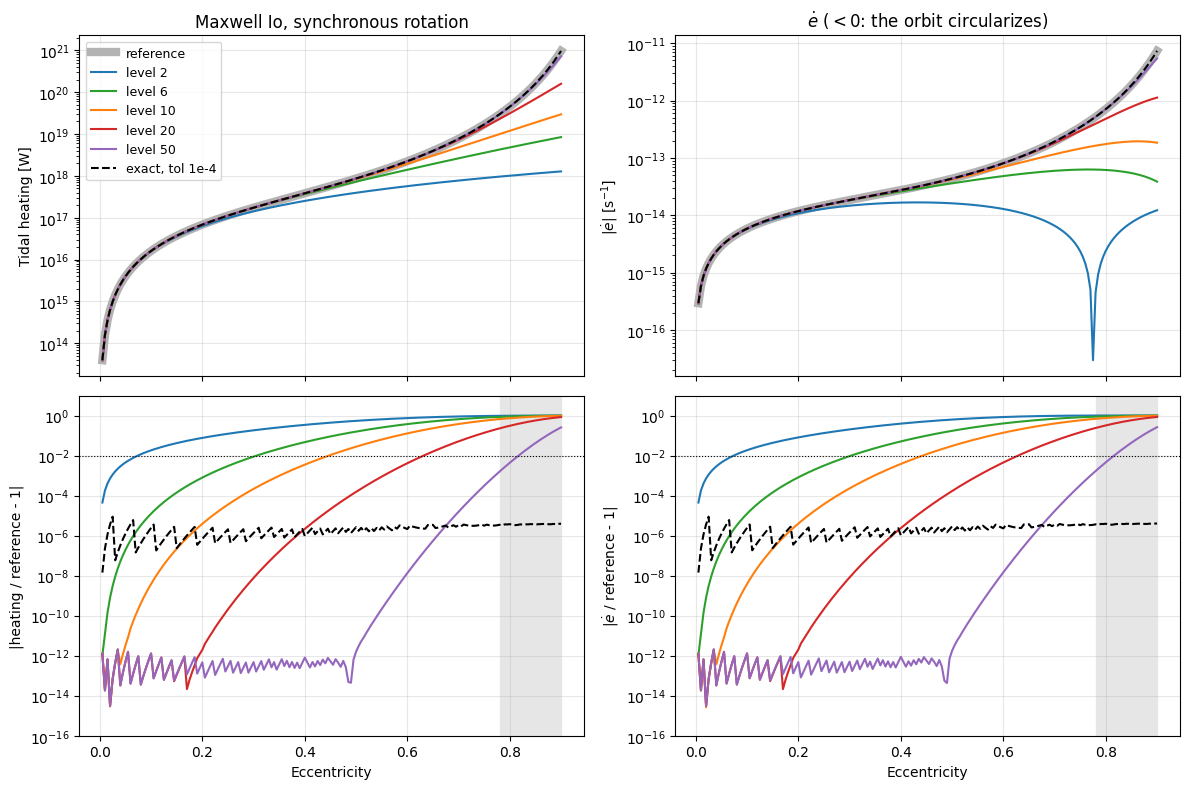

Largest eccentricity at which each level holds 1% and 1e-6 in heating and in de/dt:
  level 2           heating: 1% to 0.070, 1e-6 to 0.000;   de/dt: 1% to 0.070, 1e-6 to 0.000
  level 6           heating: 1% to 0.305, 1e-6 to 0.065;   de/dt: 1% to 0.300, 1e-6 to 0.065
  level 10          heating: 1% to 0.445, 1e-6 to 0.170;   de/dt: 1% to 0.440, 1e-6 to 0.170
  level 20          heating: 1% to 0.630, 1e-6 to 0.380;   de/dt: 1% to 0.625, 1e-6 to 0.380
  level 50          heating: 1% to 0.815, 1e-6 to 0.655;   de/dt: 1% to 0.815, 1e-6 to 0.655
  exact (tol 1e-4)  heating: 1% to 0.900, 1e-6 to 0.010;   de/dt: 1% to 0.900, 1e-6 to 0.010
Largest error of 'exact' at its default tolerance: heating 8.8e-06, de/dt 8.8e-06


In [2]:
LEVELS = (2, 6, 10, 20, 50)
COLORS = {2: "tab:blue", 4: "tab:cyan", 6: "tab:green", 8: "tab:olive", 10: "tab:orange", 20: "tab:red",
          50: "tab:purple", "exact": "k"}
eccentricities = np.linspace(0.005, 0.9, 180)

reference = np.array([evolution(io, "exact", e, exact_tolerance=1.0e-10) for e in eccentricities])
results = {level: np.array([evolution(io, level, e) for e in eccentricities]) for level in LEVELS}
results["exact"] = np.array([evolution(io, "exact", e) for e in eccentricities])   # the default tolerance, 1e-4

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for column, (name, unit) in enumerate((("Tidal heating", "W"), (r"$|\dot{e}|$", "s$^{-1}$"))):
    ax_value, ax_error = axes[0, column], axes[1, column]
    ax_value.semilogy(eccentricities, np.abs(reference[:, column]), color="0.7", lw=6, label="reference")
    for level, values in results.items():
        label = "exact, tol 1e-4" if level == "exact" else f"level {level}"
        ls = "--" if level == "exact" else "-"
        ax_value.semilogy(eccentricities, np.abs(values[:, column]), color=COLORS[level], ls=ls, label=label)
        error = np.abs(values[:, column] / reference[:, column] - 1.0)
        ax_error.semilogy(eccentricities, np.maximum(error, 1e-16), color=COLORS[level], ls=ls, label=label)
    ax_value.set_ylabel(f"{name} [{unit}]")
    ax_error.axhline(1e-2, color="k", lw=0.8, ls=":")
    ax_error.axvspan(0.78, eccentricities[-1], color="0.9", zorder=0)
    ax_error.set_ylim(1e-16, 10.0)
    ax_error.set_ylabel("|heating / reference - 1|" if column == 0 else r"$|\dot{e}$ / reference - 1|")
    ax_error.set_xlabel("Eccentricity")
    for ax in (ax_value, ax_error):
        ax.grid(alpha=0.3)
axes[0, 0].set_title("Maxwell Io, synchronous rotation")
axes[0, 1].set_title(r"$\dot{e}$ ($< 0$: the orbit circularizes)")
axes[0, 0].legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Largest eccentricity at which each level holds 1% and 1e-6 in heating and in de/dt:")
for level in LEVELS + ("exact",):
    limits = []
    for column in (0, 1):
        error = np.abs(results[level][:, column] / reference[:, column] - 1.0)
        for tolerance in (1e-2, 1e-6):
            bad = np.nonzero(error > tolerance)[0]
            limits.append(eccentricities[bad[0] - 1] if bad.size and bad[0] > 0 else
                          (0.0 if bad.size else eccentricities[-1]))
    name = "exact (tol 1e-4)" if level == "exact" else f"level {level}"
    print(f"  {name:17s} heating: 1% to {limits[0]:.3f}, 1e-6 to {limits[1]:.3f};   "
          f"de/dt: 1% to {limits[2]:.3f}, 1e-6 to {limits[3]:.3f}")
print(f"Largest error of 'exact' at its default tolerance: heating "
      f"{np.abs(results['exact'][:, 0] / reference[:, 0] - 1).max():.1e}, "
      f"de/dt {np.abs(results['exact'][:, 1] / reference[:, 1] - 1).max():.1e}")

Each level holds 1% a little further out for this body than the limits TidalPy tabulates, which are the worst case over several tide models and spin rates: level 10, the default, to $e \approx 0.44$ here against 0.31 in the table. The $e^2$ theory of level 2 is already 2% low at $e = 0.1$, and its $\dot{e}$ changes sign just below $e = 0.8$, an artifact of the truncation that Renaud et al. (2021) pointed out and that every higher level removes.

Past about $e = 0.78$ (shaded) even level 50 fails. There its highest modes are large terms of opposite sign that nearly cancel, so rounding and any error in the Love numbers are multiplied many times over. The exact option has no such limit: at its default tolerance of $10^{-4}$ it stays within $10^{-5}$ of the reference at every eccentricity.

## How Many Modes the Exact Functions Need

The exact option keeps the modes $|q| \le Q$ whose weighted squares leave a tail below its tolerance. The number of modes grows quickly with eccentricity: the eccentricity functions fall off with $q$ ever more slowly as the orbit approaches a parabola. The left panel shows the active modes of the heating sum and the right panel the distinct forcing frequencies, each of which costs a Love number solve. The markers place each tabulated level at the eccentricity where it reaches 1% accuracy (from the measured limits behind `eccentricity_accuracy_limit`).

 level  1% limit e  modes  frequencies
     2       0.020      4            1
     4       0.095      7            2
     6       0.175     11            3
     8       0.245     15            4
    10       0.310     19            5
    20       0.490     39           10
    50       0.745     99           25


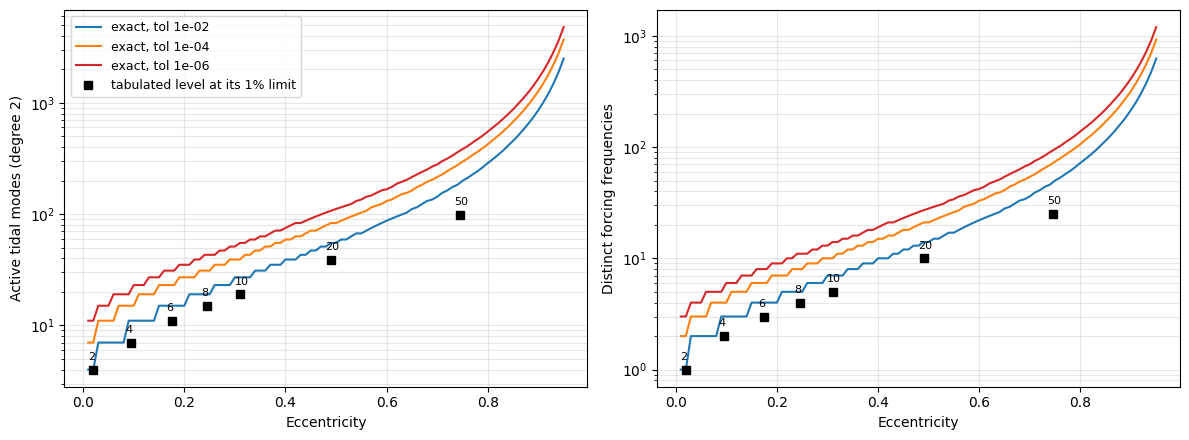

In [3]:
mode_eccentricities = np.linspace(0.01, 0.95, 95)
TOLERANCES = {1e-2: "tab:blue", 1e-4: "tab:orange", 1e-6: "tab:red"}

fig, (ax_modes, ax_frequencies) = plt.subplots(1, 2, figsize=(12, 4.5))
for tolerance, color in TOLERANCES.items():
    modes, frequencies = [], []
    for e in mode_eccentricities:
        evolution(io, "exact", e, exact_tolerance=tolerance)
        modes.append(io.get_num_tidal_modes())
        frequencies.append(unique_frequencies("exact", e, tolerance))
    ax_modes.semilogy(mode_eccentricities, modes, color=color, label=f"exact, tol {tolerance:.0e}")
    ax_frequencies.semilogy(mode_eccentricities, frequencies, color=color, label=f"exact, tol {tolerance:.0e}")

print(f"{'level':>6} {'1% limit e':>11} {'modes':>6} {'frequencies':>12}")
for level in ECCENTRICITY_TRUNCATIONS:
    limit = eccentricity_accuracy_limit(level, 1e-2)
    evolution(io, level, limit)
    modes, frequencies = io.get_num_tidal_modes(), unique_frequencies(level, limit)
    ax_modes.plot(limit, modes, "ks", ms=6)
    ax_frequencies.plot(limit, frequencies, "ks", ms=6)
    for ax, value in ((ax_modes, modes), (ax_frequencies, frequencies)):
        ax.annotate(str(level), (limit, value), textcoords="offset points", xytext=(-4, 7), fontsize=8)
    print(f"{level:6d} {limit:11.3f} {modes:6d} {frequencies:12d}")
ax_modes.plot([], [], "ks", label="tabulated level at its 1% limit")
for ax, label in ((ax_modes, "Active tidal modes (degree 2)"), (ax_frequencies, "Distinct forcing frequencies")):
    ax.set_xlabel("Eccentricity")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3, which="both")
ax_modes.legend(fontsize=9)
plt.tight_layout()
plt.show()

A tabulated level carries a fixed set of modes whatever the eccentricity, while the exact functions keep only what their tolerance asks for, so at low eccentricity they need fewer modes than a high level. At its own 1% point each level uses fewer modes than the exact functions do at a 1% tolerance: that tolerance bounds the error of the most demanding tide model, and the error it leaves is usually far smaller (the $10^{-4}$ curve above stayed within $10^{-5}$). Past $e \approx 0.75$, where the tables stop, the count climbs steeply, to over a thousand modes and several hundred forcing frequencies at $e = 0.9$.

## What Each Level Costs

Each level adds modes, and new modes can add distinct forcing frequencies, each of which needs its own Love number solve. With the homogeneous-sphere Love number used above, a solve is a closed form, so the cost is mostly the mode bookkeeping. With the radial solver, each distinct frequency is a full radial integration, and the frequency count sets the cost. Both are timed below at $e = 0.1$ for the tabulated levels, and for the exact option across eccentricity.

truncation     e  modes  freqs  heating error  homogeneous  radial solver
         2  0.10      4      1        1.8e-02      19.3 us        0.56 ms
         4  0.10      7      2        6.3e-04      20.3 us        0.93 ms
         6  0.10     11      3        1.2e-05      22.5 us        1.39 ms
         8  0.10     15      4        2.3e-07      22.1 us        1.90 ms


        10  0.10     19      5        3.8e-09      24.7 us        2.63 ms
        20  0.10     39     10        1.3e-12      32.4 us        5.99 ms


        50  0.10     99     25        1.3e-12      59.1 us       14.93 ms
     exact  0.10     15      4        2.4e-06      51.2 us        1.90 ms


     exact  0.30     39     10        1.4e-06      84.7 us        5.59 ms


     exact  0.50     83     21        2.6e-06     163.5 us       13.10 ms


     exact  0.70    215     54        3.3e-06     350.2 us       34.72 ms


     exact  0.90   1271    318        3.9e-06    3194.6 us      206.18 ms


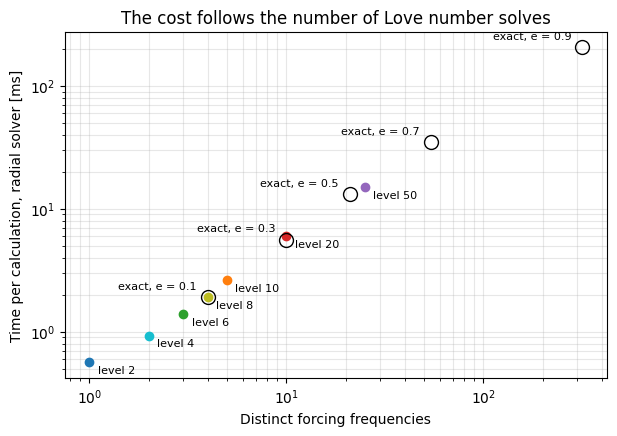

In [4]:
def time_per_call(world, level, eccentricity, number):
    "Seconds per heating calculation (best of five batches)."
    evolution(world, level, eccentricity)
    calc = SYSTEMS[id(world)].calc_world_evolution
    return min(timeit.repeat(lambda: calc(world), number=number, repeat=5)) / number


# The same body with the radial solver as its Love method, in its own system.
io_radial = maxwell_io("radial_solver")
jupiter_system(io_radial)

rows = [(level, 0.1) for level in ECCENTRICITY_TRUNCATIONS] + [("exact", e) for e in (0.1, 0.3, 0.5, 0.7, 0.9)]
print(f"{'truncation':>10} {'e':>5} {'modes':>6} {'freqs':>6} {'heating error':>14} "
      f"{'homogeneous':>12} {'radial solver':>14}")
timings = []
for level, e in rows:
    reference_heating = evolution(io, "exact", e, exact_tolerance=1.0e-10)[0]
    heating = evolution(io, level, e)[0]
    modes, frequencies = io.get_num_tidal_modes(), unique_frequencies(level, e)
    homogeneous = time_per_call(io, level, e, 200)
    radial = time_per_call(io_radial, level, e, 3)
    timings.append((level, e, frequencies, homogeneous, radial))
    print(f"{str(level):>10} {e:5.2f} {modes:6d} {frequencies:6d} {abs(heating / reference_heating - 1):14.1e} "
          f"{homogeneous * 1e6:9.1f} us {radial * 1e3:11.2f} ms")

fig, ax = plt.subplots(figsize=(7, 4.5))
for level, e, frequencies, homogeneous, radial in timings:
    color = "k" if level == "exact" else COLORS.get(level, "tab:gray")
    ax.loglog(frequencies, radial * 1e3, "o", color=color, ms=10 if level == "exact" else 6,
              mfc="none" if level == "exact" else color)
    ax.annotate(f"exact, e = {e}" if level == "exact" else f"level {level}", (frequencies, radial * 1e3),
                textcoords="offset points", xytext=(-8, 6) if level == "exact" else (6, -8), fontsize=8,
                ha="right" if level == "exact" else "left")
ax.set_xlabel("Distinct forcing frequencies")
ax.set_ylabel("Time per calculation, radial solver [ms]")
ax.set_title("The cost follows the number of Love number solves")
ax.grid(alpha=0.3, which="both")
plt.show()

The tabulated levels are cheap with a closed-form Love number, and even the exact option at $e = 0.9$ costs only a few milliseconds. With the radial solver the cost grows in step with the number of distinct frequencies, from about half a millisecond at level 2 to about 15 ms at level 50 and a fifth of a second for the exact functions at $e = 0.9$, so a level far above what the eccentricity needs is paid for in every call. In a long orbital integration, where eccentricity can be driven up by a resonance, that is the trade-off to weigh: a low level is fast, but it becomes inaccurate as the eccentricity rises. A world's `calc_tides` logs a warning, once per world, when the eccentricity passes the point where its level can be 10% low.

## Choosing a Level

`recommend_eccentricity_truncation(eccentricity, tolerance, max_degree_l)` returns the lowest tabulated level that holds a heating tolerance at an eccentricity, or `"exact"` when none does. The limits it reads were measured over constant-phase-lag, constant-time-lag, and Maxwell tides at several spin rates. Degree 3 and higher lose accuracy at a lower eccentricity than degree 2, so a solve that includes them should say so.

In [5]:
print(f"{'e':>5} {'1%, l = 2':>10} {'1%, l = 3':>10} {'1e-4, l = 2':>12} {'1e-6, l = 2':>12}")
for e in (0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9):
    print(f"{e:5.3f} {str(recommend_eccentricity_truncation(e)):>10} "
          f"{str(recommend_eccentricity_truncation(e, max_degree_l=3)):>10} "
          f"{str(recommend_eccentricity_truncation(e, tolerance=1e-4)):>12} "
          f"{str(recommend_eccentricity_truncation(e, tolerance=1e-6)):>12}")

    e  1%, l = 2  1%, l = 3  1e-4, l = 2  1e-6, l = 2
0.001          2          2            4            4
0.010          2          2            4            6
0.050          4          4            6            8
0.100          6          6            8           10
0.200          8          8           20           20
0.300         10         20           20           50
0.400         20         20           50           50
0.500         50         50           50           50
0.600         50         50           50        exact
0.700         50         50        exact        exact
0.800      exact      exact        exact        exact
0.900      exact      exact        exact        exact


## Obliquity Levels

The obliquity functions follow the same rule: level $N$ keeps every product of two of them through $I^N$. Unlike the eccentricity series these converge at every obliquity, and the general functions (`"gen"`) are exact and barely more expensive, so the truncated levels exist to drop modes at small obliquity. Level `"off"` ignores the obliquity entirely. The sweep below tilts the synchronous Io at a small eccentricity, where the obliquity tide dominates. Far past a level's range its cut squares can turn negative: level 4 does past about 65 degrees here, where its heating drops off the logarithmic axis.

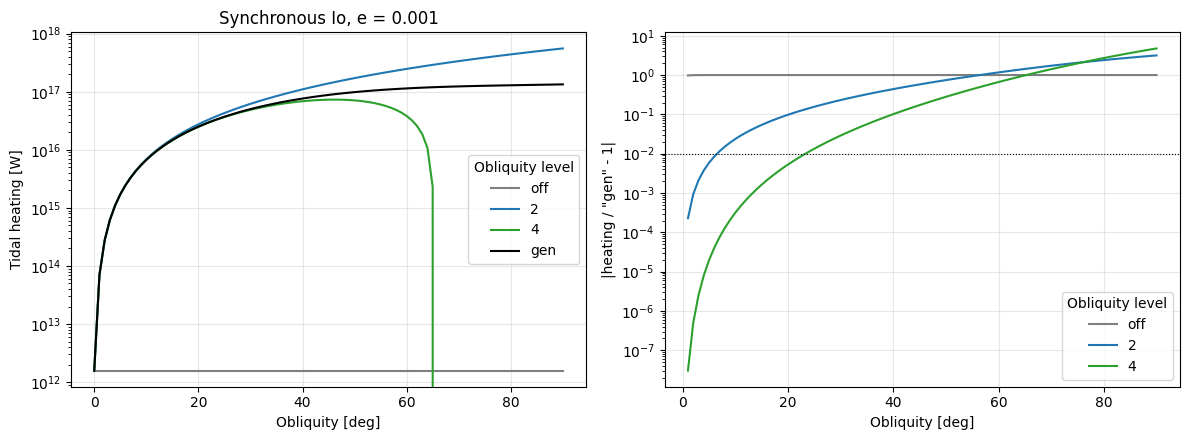

I =  1.0 deg: recommend_obliquity_truncation -> 2 (1%), 4 (1e-4)
I =  5.0 deg: recommend_obliquity_truncation -> 2 (1%), 4 (1e-4)
I = 10.0 deg: recommend_obliquity_truncation -> 4 (1%), 'gen' (1e-4)
I = 23.4 deg: recommend_obliquity_truncation -> 4 (1%), 'gen' (1e-4)
I = 45.0 deg: recommend_obliquity_truncation -> 'gen' (1%), 'gen' (1e-4)


In [6]:
obliquities = np.radians(np.linspace(0.0, 90.0, 91))
OBLIQUITY_LEVELS = {"off": "tab:gray", 2: "tab:blue", 4: "tab:green", "gen": "k"}
obliquity_heating = {level: np.array([evolution(io, 10, 0.001, obliquity=inc, obliquity_level=level)[0]
                                      for inc in obliquities]) for level in OBLIQUITY_LEVELS}
io.set_obliquity(0.0)

fig, (ax, ax_error) = plt.subplots(1, 2, figsize=(12, 4.5))
for level, color in OBLIQUITY_LEVELS.items():
    ax.semilogy(np.degrees(obliquities), obliquity_heating[level], color=color, label=f"{level}")
    if level != "gen":
        error = np.abs(obliquity_heating[level][1:] / obliquity_heating["gen"][1:] - 1.0)
        ax_error.semilogy(np.degrees(obliquities[1:]), np.maximum(error, 1e-16), color=color, label=f"{level}")
ax_error.axhline(1e-2, color="k", lw=0.8, ls=":")
ax.set_ylabel("Tidal heating [W]")
ax_error.set_ylabel('|heating / "gen" - 1|')
ax.set_title("Synchronous Io, e = 0.001")
for axis in (ax, ax_error):
    axis.set_xlabel("Obliquity [deg]")
    axis.grid(alpha=0.3)
    axis.legend(title="Obliquity level")
plt.tight_layout()
plt.show()

for degrees in (1.0, 5.0, 10.0, 23.4, 45.0):
    print(f"I = {degrees:4.1f} deg: recommend_obliquity_truncation -> "
          f"{recommend_obliquity_truncation(np.radians(degrees))!r} (1%), "
          f"{recommend_obliquity_truncation(np.radians(degrees), tolerance=1e-4)!r} (1e-4)")

## Summary

- Eccentricity level $N$ keeps every term of the heating and the orbital rates through $e^N$. Every level errs low, and a higher level is never less accurate.
- The default, level 10, is good to about 1% up to $e \approx 0.3$ in the worst case (0.44 for this Io). Level 20 reaches about 0.5 and level 50 about 0.75. Past that, use `"exact"`, whose tolerance bounds the heating error at any eccentricity below 1.
- The cost of a level is its number of distinct forcing frequencies, each a Love number solve. With the radial solver, use the lowest level that holds your tolerance over the eccentricities you expect, and let `recommend_eccentricity_truncation` pick it.
- The obliquity levels work the same way in $I$. Level 2 is good to about 8 degrees and level 4 to about 27; past that, `"gen"` is exact and cheap.